##  Pre-processing 


This notebook shows:
- How to load a 4DSTEM dataset.
- Mask pixels
- Calibration
- Save Vacuum Probe

### Authors

This tutorial was created by the py4DSTEM instructor team:
- Colin Ophus (cophus@gmail.com)
- Ben Savitzky (bhsavitzky@lbl.gov)
- Stephanie Ribet (sribet@lbl.gov)

Last updated: 2025 May 3

In [35]:
# This painful import cell is required because of incompatbility between colab's
# version of numpy and the version required by py4DSTEM.

import numpy as np
import py4DSTEM as p4
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import os
import sys
# List h5 files in path directory containing "master" in filename
# path = "/Volumes/Extreme SSD/Data/250806/"
path = 'D:\\_Data\\250806\\'
h5_files = [f for f in os.listdir(path) if f.endswith('.h5') and 'master' in f]
print("\nH5 files containing 'master':")
for f in h5_files:
    print(f)



H5 files containing 'master':
250801_Au_2mrad_145mm_00_master.h5
250801_Au_2mrad_185mm_00_master.h5
250801_JJ_2mrad_145mm_00_master.h5
250801_JJ_2mrad_145mm_00_master_masked.h5
250801_JJ_2mrad_145mm_01_master.h5
250801_JJ_2mrad_145mm_01_master_masked.h5
250801_JJ_2mrad_145mm_02_master.h5
250801_JJ_2mrad_145mm_03_master.h5
250801_JJ_2mrad_145mm_04_master.h5
250801_JJ_2mrad_185mm_00_master.h5
250801_JJ_2mrad_185mm_01_master.h5
250801_JJ_2mrad_185mm_02_master.h5
250801_JJ_2mrad_185mm_03_master.h5


# Load data

In [4]:
# set the path to the local copy of the dataset file
name = "250801_Au_2mrad_145mm_00_master"
filepath_data = path + name + ".h5"

# load the data
datacube = p4.import_file(filepath_data)

# print results
print(datacube)

Dataset is uint32 but will be converted to uint16
DataCube( A 4-dimensional array of shape (256, 256, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0,1,2,...] pixels
              Ry = [0,1,2,...] pixels
              Qx = [0,1,2,...] pixels
              Qy = [0,1,2,...] pixels
)


In [5]:
# Examine the file contents
p4.print_h5_tree( filepath_data )

/
|---entry
    |---data
    |---instrument
    |   |---beam
    |   |---detector
    |       |---detectorSpecific
    |       |---geometry
    |       |   |---orientation
    |       |   |---translation
    |       |---goniometer
    |       |---module
    |       |---transformations
    |---sample
        |---beam
        |---goniometer
        |---transformations




# Examine individual and mean

In [6]:
np.max(datacube.data)

65535

In [7]:
# Mean and max diffraction pattern of the calibration and measurement datasets
dp_mean = datacube.get_dp_mean()
dp_max = datacube.get_dp_max()

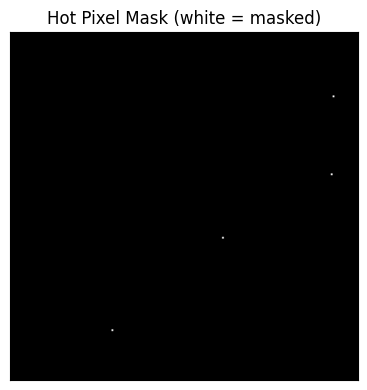

Maximum value 5558


In [8]:
dataset_masked = []
for data in [datacube,]:
    mask_hotpixel = data.tree('dp_mean').data>65530
    masked = data.median_filter_masked_pixels(mask = mask_hotpixel, kernel_width = 5)
    masked.get_dp_max();
    masked.get_dp_mean();
    # Plot the hot pixel mask
    p4.show(
        mask_hotpixel,
        cmap='gray',
        figsize=(4,4),
        ticks=False,
        title='Hot Pixel Mask (white = masked)',
    )
    plt.show()
    dataset_masked.append(masked)
    print('Maximum value', np.max(masked.tree('dp_max').data))
datacube_masked = dataset_masked[0]

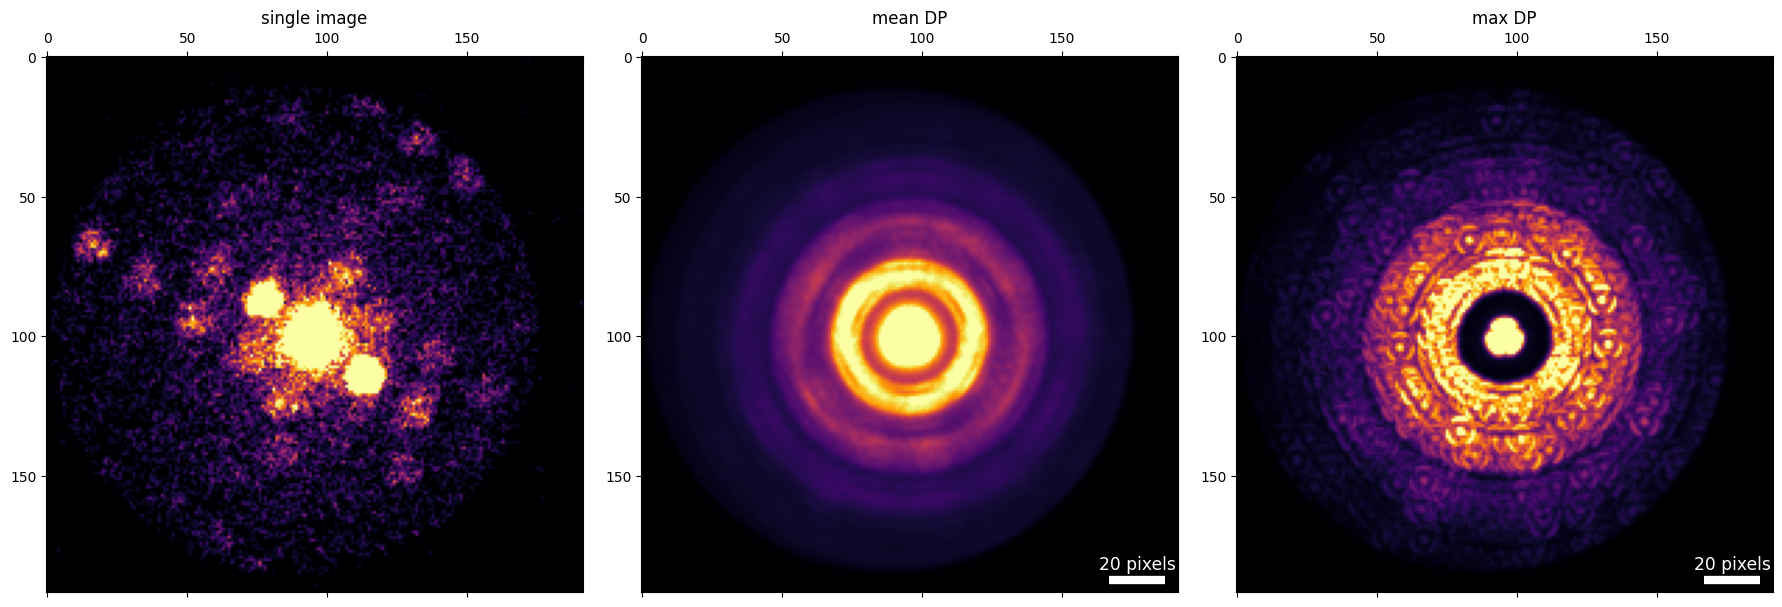

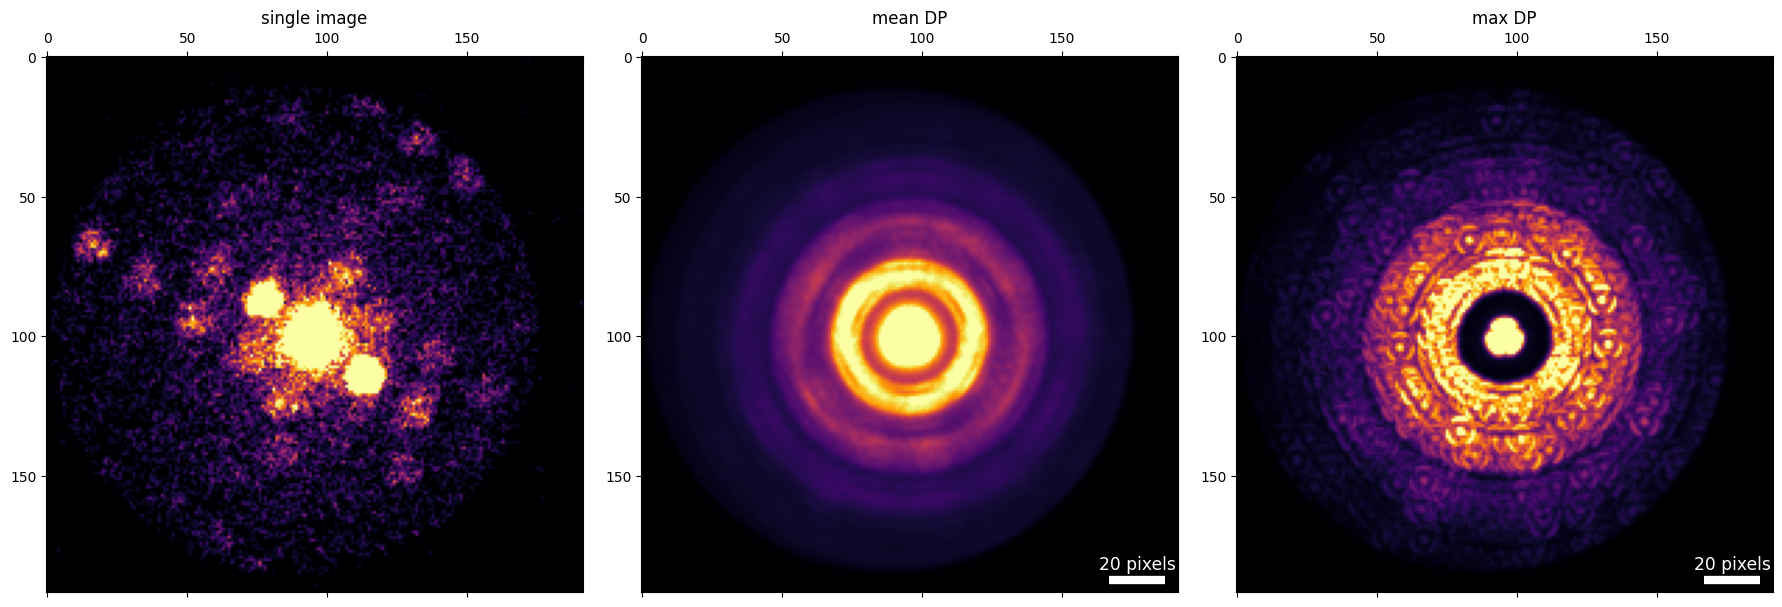

In [10]:
# show
p4.show(
    [
        datacube_masked.data[40,20],
        datacube_masked.get_dp_mean(),
        datacube_masked.get_dp_max(),
    ],
    cmap = 'inferno',
    title = ['single image','mean DP','max DP'],
    # power = 1,
)
plt.show()

Note that the center spot is shaped like a "rounded rectangle."  What you are seeing is the circular center spot, convolved with a rectangle shape corresponding to the STEM probe descan on the detector.  This is a shift of each diffraction pattern as a function of the STEM probe position. We will need to measure and correct these shifts.

In [9]:

# p4.save(
#     data = datacube_masked,
#     filepath = path + f'{name}_masked.h5',)


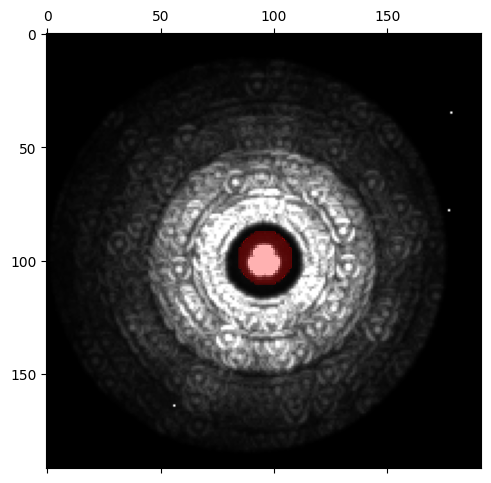

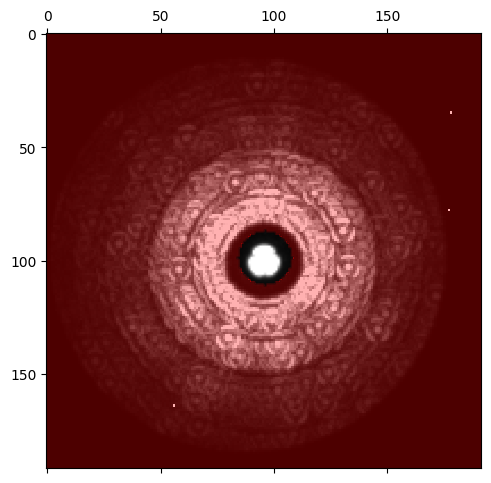

In [11]:
# Virtual imaging - position the detectors

# We'll generate a bright-field (BF) and an annular dark-field (ADF) virtual image
# for both the calibration and measurement datasets

# Set the center
center = (99,96)

# set the geometries
radius_bf = 12
geometry_bf = (center,radius_bf)
geometry_adf = (center,(radius_bf,10e3))

# display the detector positions
datacube_masked.position_detector(
    data = dp_max,
    mode = 'circle',
    geometry = geometry_bf,
)
datacube_masked.position_detector(
    data = dp_max,
    mode = 'annulus',
    geometry = geometry_adf,
)

100%|██████████| 65536/65536 [00:03<00:00, 16783.03it/s]


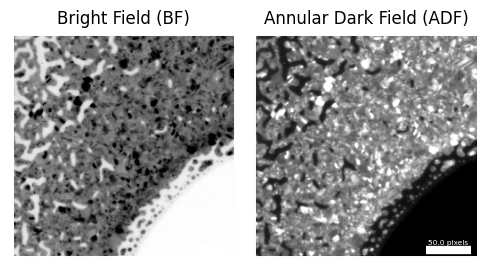

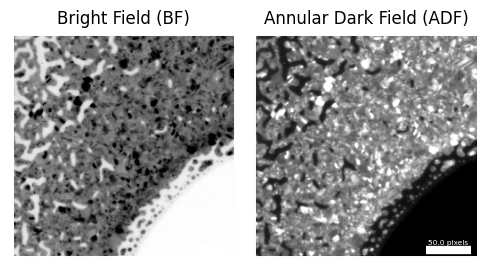

In [13]:
# Virtual imaging - compute the images

# compute
im_bf = datacube_masked.get_virtual_image(
    mode = 'circle',
    geometry = geometry_bf,
    name = 'bright_field_cal',
)
im_adf = datacube_masked.get_virtual_image(
    mode = 'annulus',
    geometry = geometry_adf,
    name = 'dark_field_cal',
)

# show
p4.show(
    [im_bf,im_adf],
    figsize=(16,2),
    bordercolor = 'w',
    cmap='gray',
    title=['Bright Field (BF)','Annular Dark Field (ADF)'],
    axsize = (2.5,4),
)
plt.show()

# Construct probe template

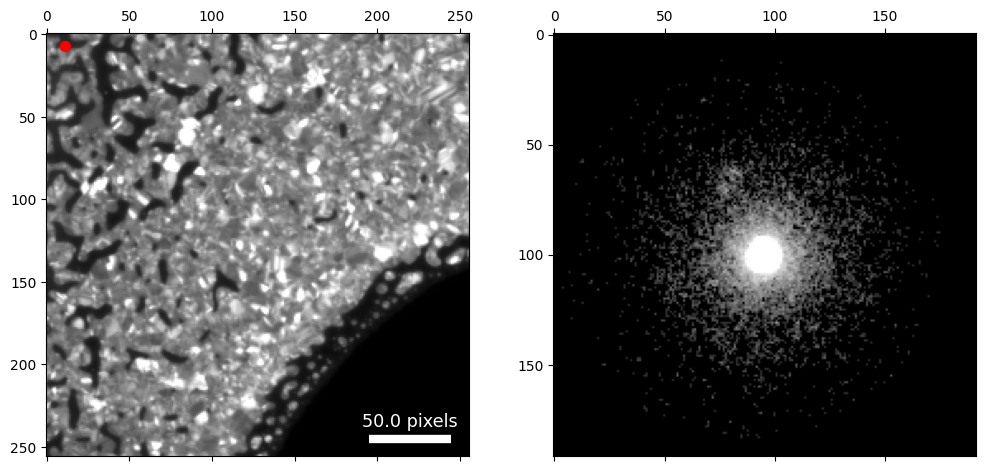

In [14]:
# Examine scan points for a vacuum probe

rx,ry = 7,11

p4.visualize.show_selected_dp(
    datacube_masked,
    im_adf,
    rx,
    ry
)

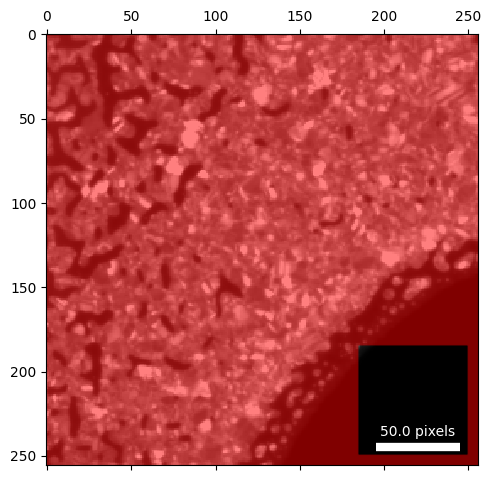

In [18]:
# Select a vacuum region

xlims = 185,250
ylims = 185, 250

ROI = np.zeros(datacube_masked.rshape, dtype=bool)
ROI[xlims[0]:xlims[1], ylims[0]:ylims[1]] = True

p4.show(
    im_adf,
    mask = ROI,
    mask_color = 'r',
    mask_alpha = 0.5
)

100%|██████████| 4224/4224 [00:14<00:00, 286.46it/s]


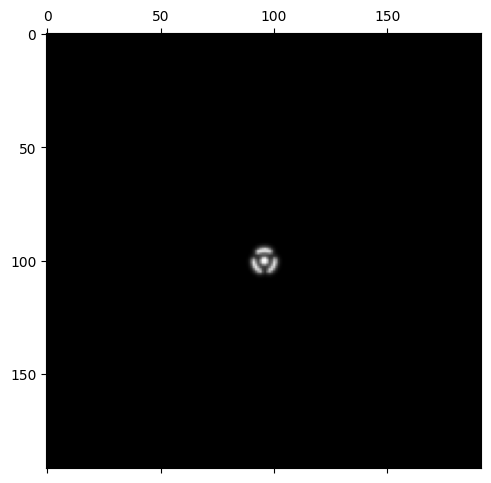

In [19]:
probe = datacube_masked.get_vacuum_probe(
    ROI = ROI,
)

p4.show(
    probe.probe,
    vmax=1,
)

In [20]:
probe.probe

array([[0.00343082, 0.00418876, 0.00284091, ..., 0.00307765, 0.00209438,
        0.0032021 ],
       [0.00209438, 0.00189394, 0.00236742, ..., 0.00118371, 0.00213068,
        0.00279251],
       [0.00213068, 0.00189394, 0.00355114, ..., 0.00118371, 0.00142045,
        0.00355114],
       ...,
       [0.00307765, 0.00260417, 0.00236742, ..., 0.0016572 , 0.00260417,
        0.00260417],
       [0.00372334, 0.00284091, 0.00236742, ..., 0.00118371, 0.00189394,
        0.00302522],
       [0.00617548, 0.00325793, 0.00426136, ..., 0.00260417, 0.00488689,
        0.00228722]])

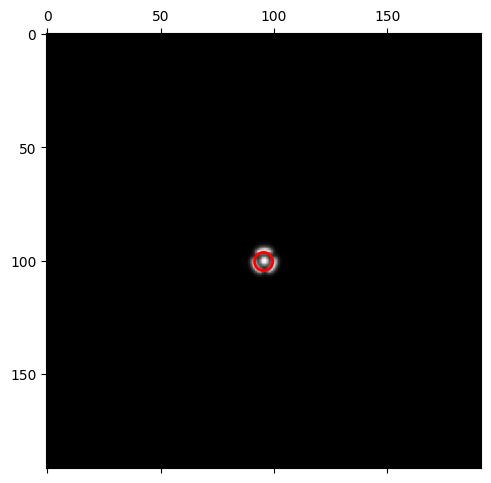

In [21]:
# Estimate the radius of the BF disk

probe_semiangle, probe_qx0, probe_qy0 = p4.process.calibration.get_probe_size(probe.probe)

p4.show(
    probe.probe,
    circle = {
        'center' : (probe_qx0,probe_qy0),
        'R' : probe_semiangle,
    },
    vmax = 1,
)

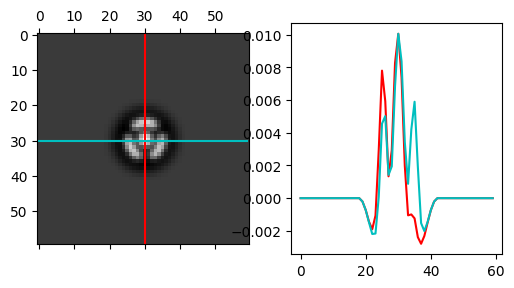

In [22]:
probe.get_kernel(
    mode = 'sigmoid',
    origin = (probe_qx0,probe_qy0),
    radii = (probe_semiangle * 1,
             probe_semiangle * 3,
    )
)

p4.visualize.show_kernel(
    probe.kernel,
    R = 30,
    L = 30,
    W = 1,
    figsize = (6,3),
)

# Find Bragg Peaks

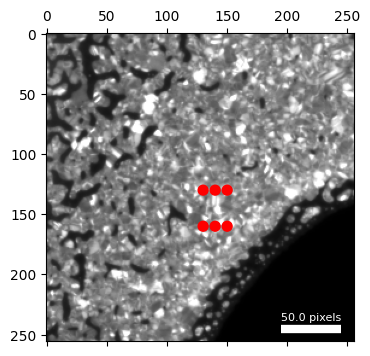

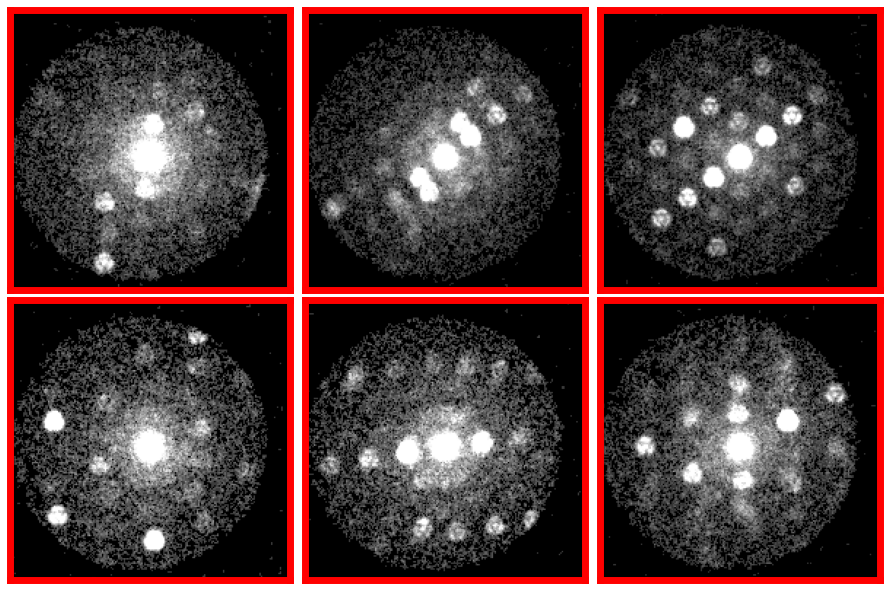

In [26]:
# Choose some diffraction patterns to use for hyperparameter tuning

rxs = 130,130,130,160,160,160
rys = 130,140,150,130,140,150

colors=['r','r','r','r','r','r']


p4.visualize.show_points(
    im_adf,
    x=rxs,
    y=rys,
    pointcolor=colors,
    figsize=(4,4)
)

p4.visualize.show_image_grid(
    get_ar = lambda i:datacube_masked.data[rxs[i],rys[i],:,:],
    H=2,
    W=3,
    axsize=(3,3),
    power = 0.5,
    get_bordercolor = lambda i:colors[i],
)
plt.show()

In [27]:
bg_med = np.median(datacube_masked.data)

def sub_bg(
    im,
    bg_fft=50,
    bg_real = 35,
):
    im_fft = np.fft.fft2(im)
    im_fft = np.maximum(np.abs(im_fft)-bg_fft,0.0) \
        * np.exp(1j * np.angle(im_fft))
    # im_out = np.maximum(np.real(np.fft.ifft2(im_fft)) - bg_real,0.0)
    im_out = np.real(np.fft.ifft2(im_fft)) - bg_real
    return im_out

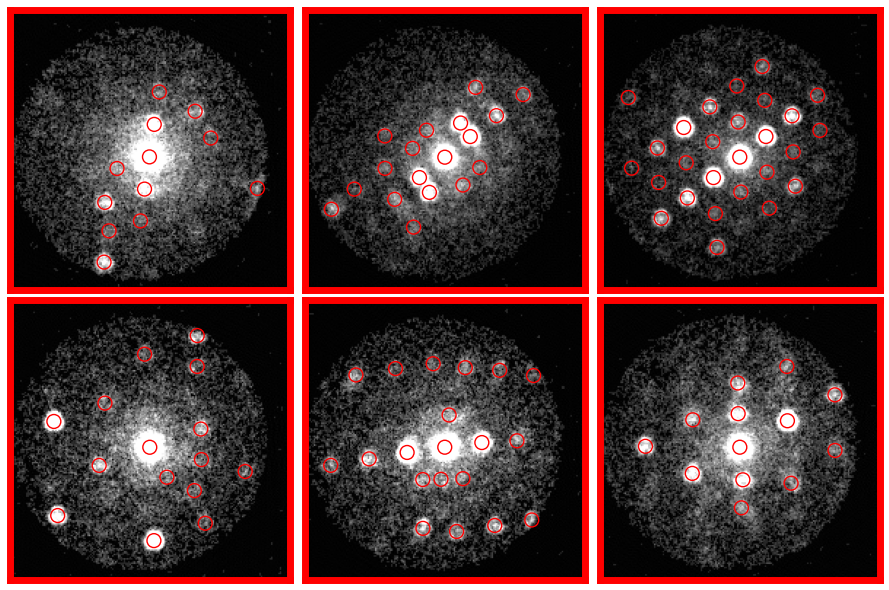

In [30]:
# Tune disk detection parameters

# disk detection parameters
detect_params = {
    'corrPower': 1,
    'sigma': 0,
    'edgeBoundary': 8,
    'minRelativeIntensity': 0.0001,
    'minAbsoluteIntensity': .8,
    'minPeakSpacing': 10,
    'subpixel': 'poly',
    'subpixel' : 'multicorr',
    'upsample_factor': 8,
    'maxNumPeaks': 200,
#     'CUDA': True,
    # 'filter_function': sub_bg,
}
# Note that "poly" subpixel fitting can be used to keep this tutoral fast, but "multicorr"
# is more accurate. For high precision strain mapping, subpixel="multicorr" is recommended.


# find the selected disks
disks_selected = datacube_masked.find_Bragg_disks(
    data = (rxs, rys),
    template = probe.kernel,
    **detect_params,
)

# show
p4.visualize.show_image_grid(
    # get_ar = lambda i:datacube.data[rxs[i],rys[i],:,:],
    get_ar = lambda i:sub_bg(datacube_masked.data[rxs[i],rys[i],:,:]),
    H=2,
    W=3,
    axsize=(3,3),
    power = .5,
    get_bordercolor = lambda i:colors[i],
    get_x = lambda i: disks_selected[i].data['qx'],
    get_y = lambda i: disks_selected[i].data['qy'],
    get_pointcolors = lambda i: colors[i],
    open_circles = True,
    scale = 100,
    # vmin = 0,
    # vmax = 0.,
)
plt.show()

In [21]:
raise Exception("Not implemented")

Exception: Not implemented

In [31]:
# Find Bragg peaks in all probe positions.

braggpeaks = datacube_masked.find_Bragg_disks(
    template = probe.kernel,
    **detect_params,
)

Finding Bragg Disks: 100%|██████████| 65.5k/65.5k [07:55<00:00, 138DP/s] 


In [32]:
file_braggdisks_raw = path+ name + '_braggdisks_raw.h5'
p4.save(
    file_braggdisks_raw,
    braggpeaks,
    mode='o',
)

100%|██████████| 65536/65536 [00:07<00:00, 8801.14it/s]


In [ ]:
peaks = p4.read(path + name + '_braggdisks_raw.h5')

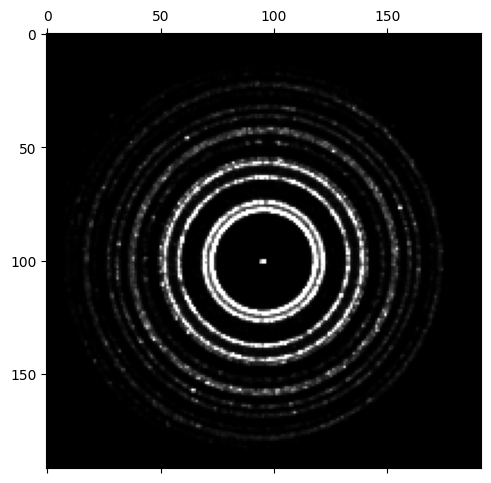

In [33]:
p4.show( braggpeaks.histogram() )

# Calibration

## Center coordinate system

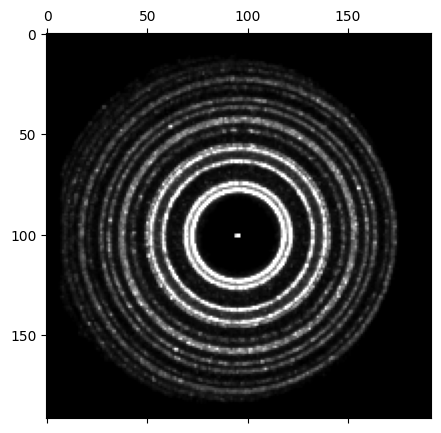

In [39]:
# Compute a Bragg vector map,
# i.e. a 2D histogram of the Bragg peak positions,
# weighted by their correlation intensities

bvm_raw = braggpeaks.histogram(mode = 'raw')

# Plot the BVM
bvm_vis_params = {
    'scaling':'power',
    'power':0.5,
}
p4.show(
    bvm_raw,
    **bvm_vis_params,
    returnfig = True
)
plt.show()

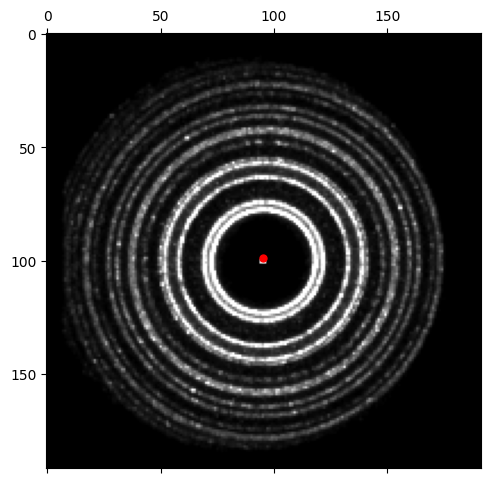

In [41]:
# Initial guess for the center position

center_guess = 99,95

p4.show(
    bvm_raw,
    points = {'x':center_guess[0],'y':center_guess[1]},
    **bvm_vis_params,
)

In [42]:
# Find the origin at each beam position

# measure the origin
qx0_meas,qy0_meas,mask_meas = braggpeaks.measure_origin( center_guess=center_guess )


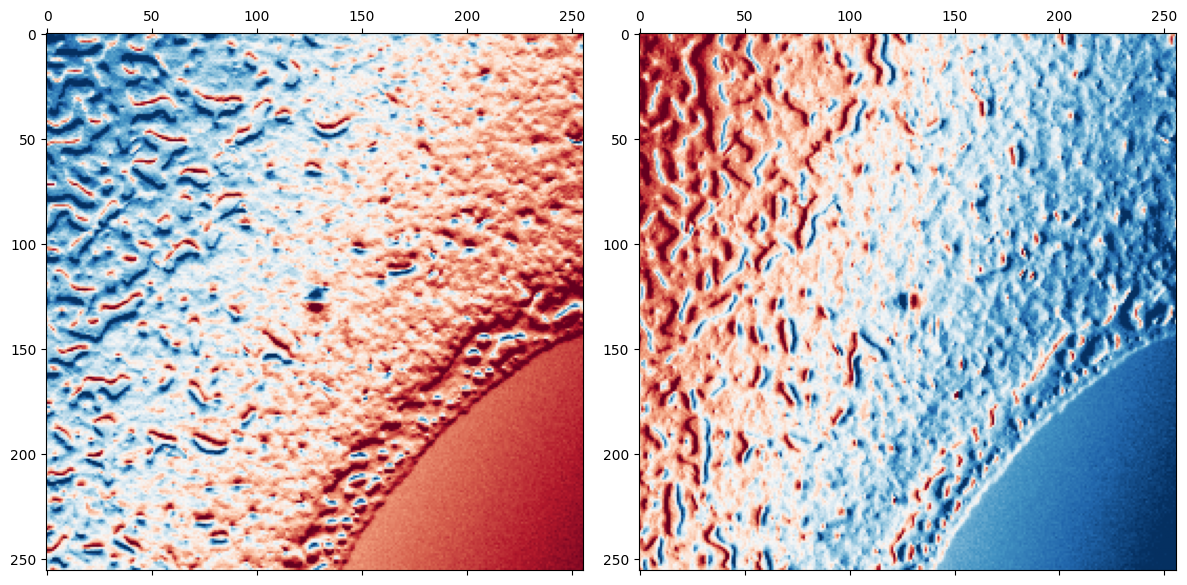

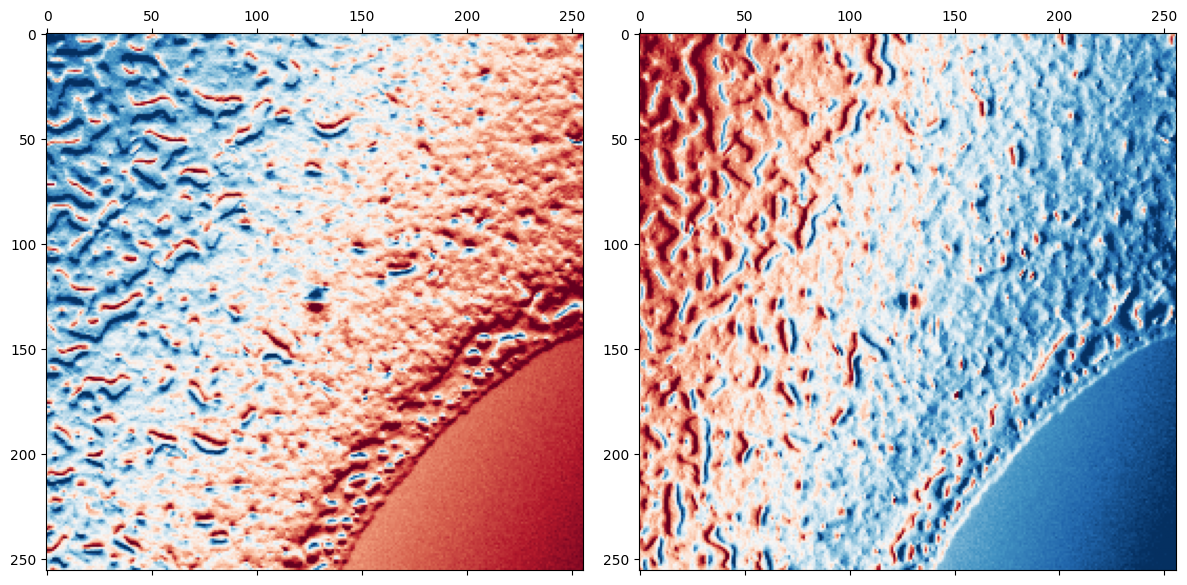

In [44]:
p4.show(
    [qx0_meas,qy0_meas],
    cmap = 'RdBu',
    mask = mask_meas
)
plt.show()

In [45]:
print( braggpeaks.calibration.get_origin_meas()[0] is qx0_meas )
print( braggpeaks.calibration.get_origin_meas()[1] is qy0_meas )

True
True


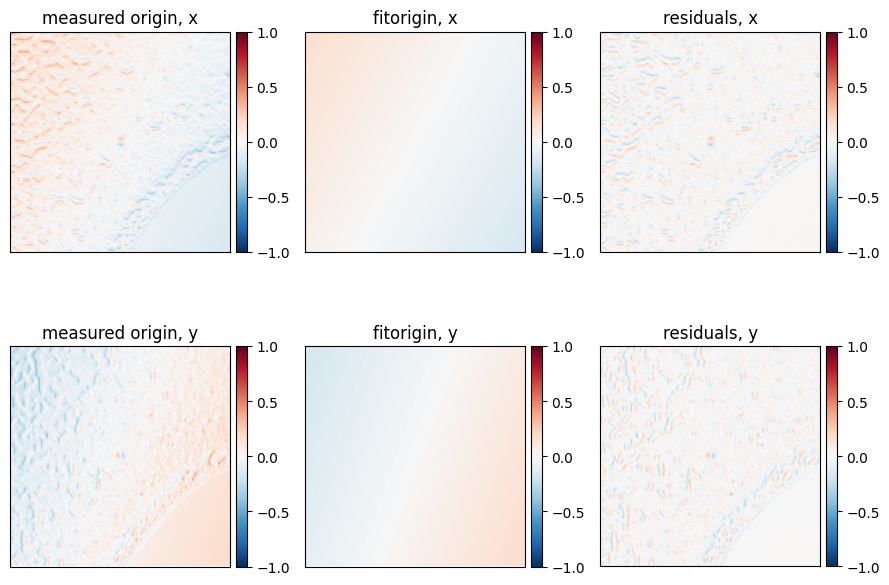

In [46]:

# fit a 2D plane
qx0_fit,qy0_fit,qx0_residuals,qy0_residuals = braggpeaks.fit_origin(
    ticks = False,
    plot_range = 1,
    axsize = (3,4),
)
plt.show()

In [47]:
braggpeaks.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:       1
             R_pixel_size:       1
             Q_pixel_units:      pixels
             R_pixel_units:      pixels
             QR_flip:            False
             qx0_meas:           2D-array
             qy0_meas:           2D-array
             origin_meas_mask:   2D-array
             qx0:                2D-array
             qx0_mean:           100.45438545759089
             qx0_shift:          2D-array
             qy0:                2D-array
             qy0_mean:           95.35432283349823
             qy0_shift:          2D-array
)

In [48]:

braggpeaks.calstate

{'center': True, 'ellipse': False, 'pixel': False, 'rotate': False}

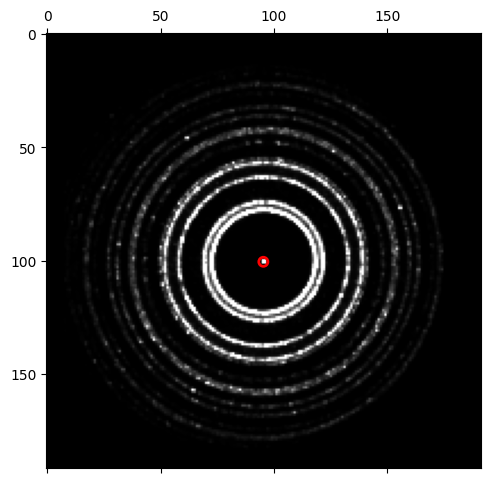

In [49]:
# Get the Bragg vector map after centering using our new origin measurements

# compute
bvm_centered = braggpeaks.histogram()

p4.show(
    bvm_centered,
    circle = {
        'center' : bvm_centered.origin,
        'R' : 2,
    },
    vmin=0,
    vmax=0.98
)

In [50]:
bvm_centered.origin

(100.45438545759089, 95.35432283349823)

### Calibrate Ellipticity

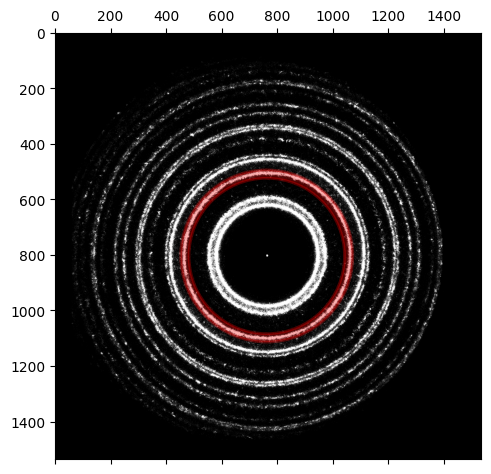

In [54]:
q_range = (280, 310)
sampling = 8
bvm_c = braggpeaks.histogram( mode='cal', sampling=sampling )

p4.show(
    bvm_c,
    cmap='gray',
    intensity_range='absolute',
    vmin=0,
    vmax=1e1,
    annulus={
        'center':bvm_c.origin,
        'radii': q_range,'fill':True,'color':'r','alpha':0.3}
)

In [55]:
# Fit the elliptical distortions
p_ellipse = p4.process.calibration.fit_ellipse_1D(
    bvm_c,
    center = bvm_c.origin,
    fitradii = q_range,
)


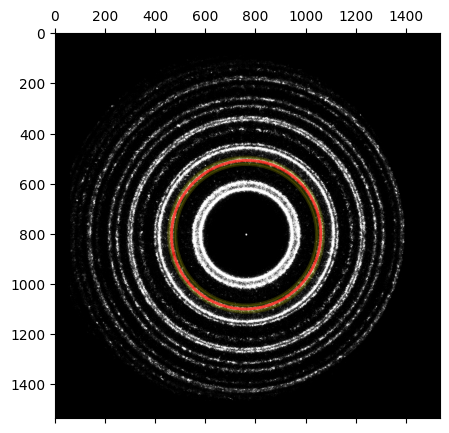

In [56]:

# plot the fit
p4.visualize.show_elliptical_fit(
    bvm_c,
    q_range,
    p_ellipse,
    cmap='gray',
    intensity_range='absolute',
    vmin=0,
    vmax=1e1,
)

In [57]:
p_ellipse

(803.730836565683,
 762.6691416045827,
 299.020857516154,
 295.37328212972835,
 -0.9946421301503511)

In [58]:
braggpeaks.calibration.set_p_ellipse(p_ellipse)

In [59]:
braggpeaks.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:       1
             R_pixel_size:       1
             Q_pixel_units:      pixels
             R_pixel_units:      pixels
             QR_flip:            False
             qx0_meas:           2D-array
             qy0_meas:           2D-array
             origin_meas_mask:   2D-array
             qx0:                2D-array
             qx0_mean:           100.45438545759089
             qx0_shift:          2D-array
             qy0:                2D-array
             qy0_mean:           95.35432283349823
             qy0_shift:          2D-array
             a:                  299.020857516154
             b:                  295.37328212972835
             theta:              -0.9946421301503511
)

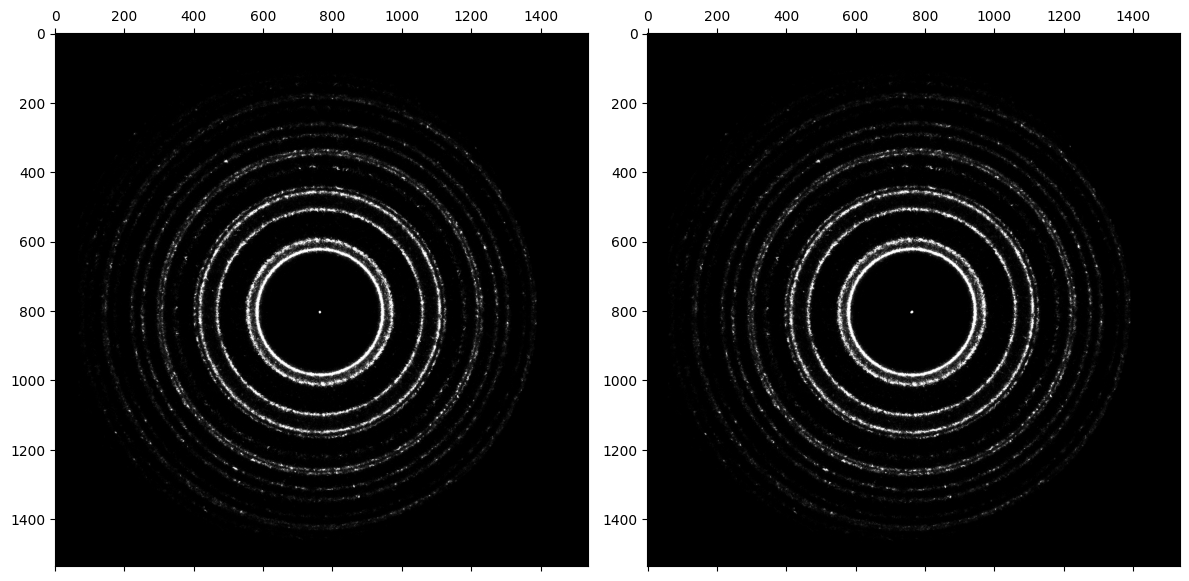

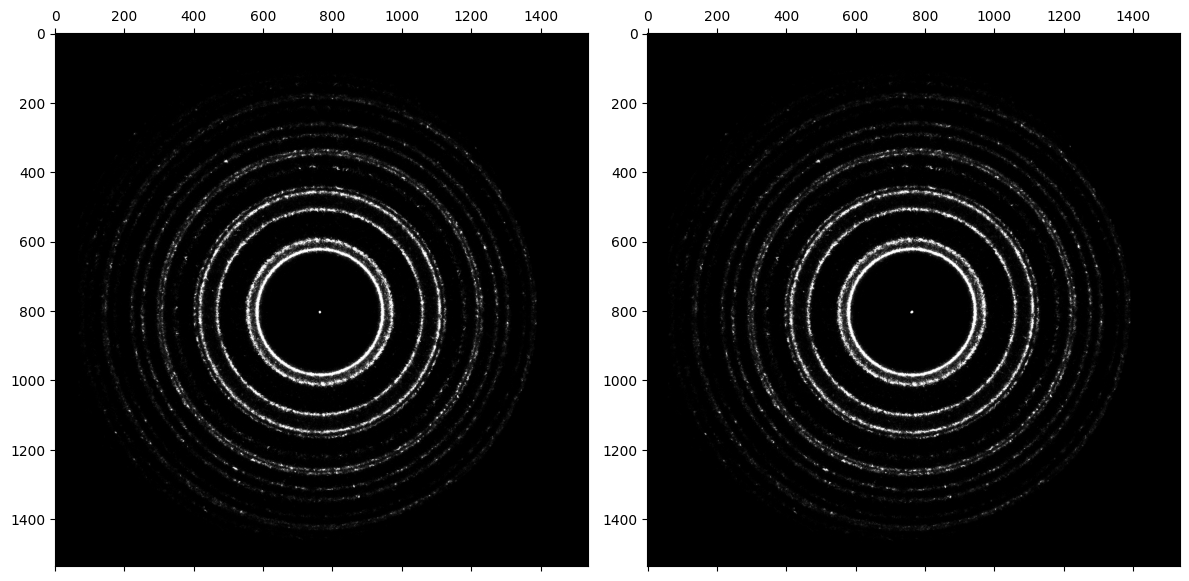

In [61]:
# Calibrate, compute a new bragg vector map, and compare

braggpeaks.setcal()
bvm_e = braggpeaks.histogram(
    sampling=sampling
)
bvm_r = braggpeaks.histogram( mode='raw', sampling=sampling )

p4.show([bvm_e, bvm_r],vmax=0.99)
plt.show()

## Calibrate detector size

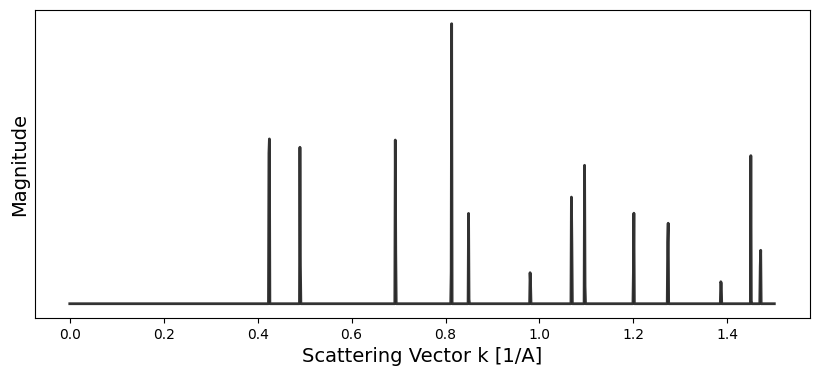

In [65]:
# Define gold structure 


# set lattice parameter and Z-number
a_lat = 4.08
atom_num = 79

# set max scattering angle, in inverse Angstroms
k_max = 1.5


# Define lattice
pos = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.5, 0.5],
    [0.5, 0.0, 0.5],
    [0.5, 0.5, 0.0],
])

# Make crystal
crystal = p4.process.diffraction.Crystal(
    pos, 
    atom_num, 
    a_lat)

# Calculate structure factors
crystal.calculate_structure_factors(k_max)

# Show
crystal.plot_scattering_intensity()
plt.show()

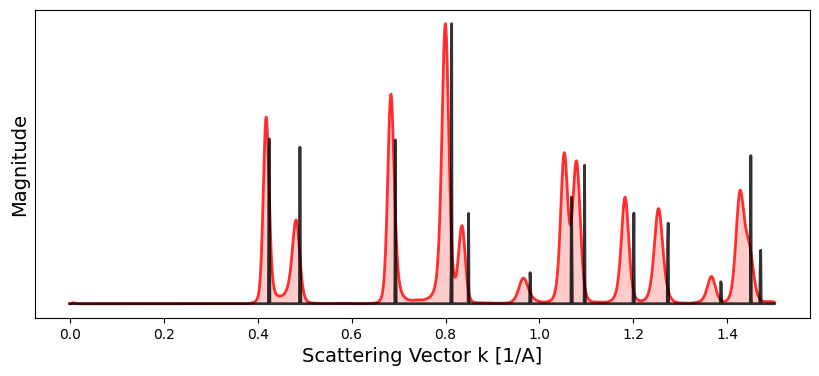

In [68]:
pixel_size_inv_Ang_guess = 0.0185


# calibrate
braggpeaks.calibration.set_Q_pixel_size(pixel_size_inv_Ang_guess)
braggpeaks.calibration.set_Q_pixel_units('A^-1')
braggpeaks.setcal()

# show overlay
crystal.plot_scattering_intensity(
    bragg_peaks = braggpeaks,
    bragg_k_power = 2.0
)
plt.show()

Calibrated pixel size = 0.01879569 A^-1


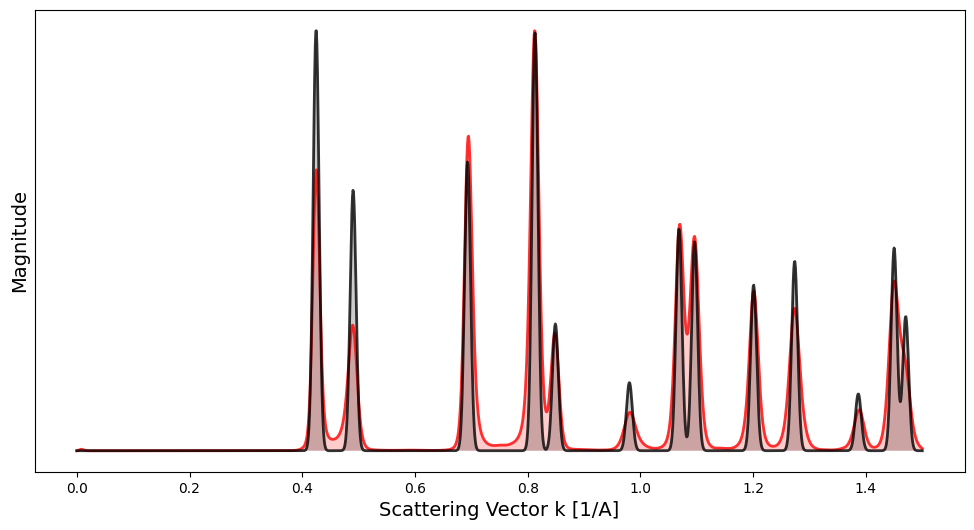

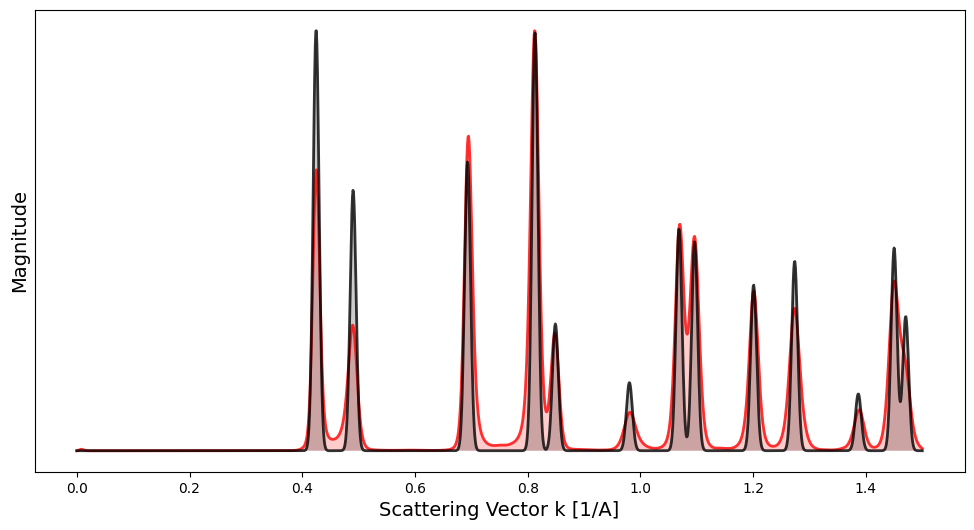

In [70]:
crystal.calibrate_pixel_size(
    bragg_peaks = braggpeaks,
    bragg_k_power = 2.0,
    plot_result = True,
);
plt.show()

In [71]:
braggpeaks.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:       0.0185
             R_pixel_size:       1
             Q_pixel_units:      A^-1
             R_pixel_units:      pixels
             QR_flip:            False
             qx0_meas:           2D-array
             qy0_meas:           2D-array
             origin_meas_mask:   2D-array
             qx0:                2D-array
             qx0_mean:           100.45438545759089
             qx0_shift:          2D-array
             qy0:                2D-array
             qy0_mean:           95.35432283349823
             qy0_shift:          2D-array
             a:                  299.020857516154
             b:                  295.37328212972835
             theta:              -0.9946421301503511
)

In [72]:
datacube_masked.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:       0.0185
             R_pixel_size:       1
             Q_pixel_units:      A^-1
             R_pixel_units:      pixels
             QR_flip:            False
             qx0_meas:           2D-array
             qy0_meas:           2D-array
             origin_meas_mask:   2D-array
             qx0:                2D-array
             qx0_mean:           100.45438545759089
             qx0_shift:          2D-array
             qy0:                2D-array
             qy0_mean:           95.35432283349823
             qy0_shift:          2D-array
             a:                  299.020857516154
             b:                  295.37328212972835
             theta:              -0.9946421301503511
)

In [78]:
f'{path}{name}_masked.h5'

'D:\\_Data\\250806\\250801_Au_2mrad_145mm_00_master_masked.h5'

In [73]:
p4.save(
    data = datacube_masked,
    filepath = f'{path}{name}_masked.h5',
    mode = 'overwrite',
)

100%|██████████| 65536/65536 [00:07<00:00, 9240.07it/s]


In [74]:
probe.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:       0.0185
             R_pixel_size:       1
             Q_pixel_units:      A^-1
             R_pixel_units:      pixels
             QR_flip:            False
             qx0_meas:           2D-array
             qy0_meas:           2D-array
             origin_meas_mask:   2D-array
             qx0:                2D-array
             qx0_mean:           100.45438545759089
             qx0_shift:          2D-array
             qy0:                2D-array
             qy0_mean:           95.35432283349823
             qy0_shift:          2D-array
             a:                  299.020857516154
             b:                  295.37328212972835
             theta:              -0.9946421301503511
)

In [75]:
p4.save(
    data = probe,
    filepath = f'{path}{name}_probe.h5',
    mode = 'overwrite',
)

In [77]:
p4.save(
    data = braggpeaks,
    filepath = path + name + '_braggpeaks.h5',
    # mode = 'overwrite',
)

  0%|          | 0/65536 [00:00<?, ?it/s]

100%|██████████| 65536/65536 [00:07<00:00, 9240.90it/s]
